In [5]:
# ============================================================
# MODELO 1: CLUSTERING NO SUPERVISADO (K-MEANS)
# ============================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression  # <--- NUEVO: Modelo 1
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns


# Cargar el dataset original
df_original = pd.read_csv('Med_plants.csv')
Med_Plants = df_original.copy()



In [6]:
# ============================================================
# MODELO 1: CLUSTERING NO SUPERVISADO (K-MEANS)
# ============================================================
# CREAR EL FILTRADO AQUÍ MISMO
df_wheat_barley = Med_Plants[Med_Plants['Cereal'].isin(['barley', 'wheat'])].copy()

# Codificar variables categóricas (igual que hiciste en tu notebook)
from sklearn.preprocessing import LabelEncoder

le_periodo = LabelEncoder()
le_cuenca = LabelEncoder()

df_wheat_barley['Periodo_encoded'] = le_periodo.fit_transform(df_wheat_barley['Chronological_Period_clean'])
df_wheat_barley['Cuenca_encoded'] = le_cuenca.fit_transform(df_wheat_barley['Mediterranean_Basin'])
df_wheat_barley['Cereal_encoded'] = (df_wheat_barley['Cereal'] == 'wheat').astype(int)

print("✅ Librerías importadas y datos filtrados")
print(f"📊 df_wheat_barley: {df_wheat_barley.shape[0]} filas, {df_wheat_barley.shape[1]} columnas")
print(f"   Cebadas (barley): {(df_wheat_barley['Cereal'] == 'barley').sum()}")
print(f"   Trigos (wheat): {(df_wheat_barley['Cereal'] == 'wheat').sum()}")

✅ Librerías importadas y datos filtrados
📊 df_wheat_barley: 1147 filas, 23 columnas
   Cebadas (barley): 586
   Trigos (wheat): 561


In [7]:
# ============================================================
# PREPARAR DATOS PARA CLUSTERING
# ============================================================

features_clustering = [
    'IRMS_d13C_Collagen',
    'd15N_Collagen', 
    'Latitude_N',
    'Longitude_E',
    'Periodo_encoded',
    'Cuenca_encoded'
]

print("📋 Variables que usaremos para clustering:")
for f in features_clustering:
    print(f"   - {f}")

# Eliminar filas con NaN en estas columnas
df_cluster = df_wheat_barley[features_clustering].dropna()

print(f"\n✅ Datos limpios: {df_cluster.shape[0]} muestras, {df_cluster.shape[1]} variables")
print(f"   Filas eliminadas por NaN: {df_wheat_barley.shape[0] - df_cluster.shape[0]}")

📋 Variables que usaremos para clustering:
   - IRMS_d13C_Collagen
   - d15N_Collagen
   - Latitude_N
   - Longitude_E
   - Periodo_encoded
   - Cuenca_encoded

✅ Datos limpios: 1147 muestras, 6 variables
   Filas eliminadas por NaN: 0


In [8]:
# ============================================================
# ESCALADO DE DATOS
# ============================================================

scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(df_cluster)

print("✅ Datos escalados (media=0, desviación=1)")
print(f"   Shape de la matriz escalada: {X_cluster_scaled.shape}")

✅ Datos escalados (media=0, desviación=1)
   Shape de la matriz escalada: (1147, 6)


🔍 Calculando inercia para k = 2 a 8...
   k = 2 → inercia = 5152.04
   k = 3 → inercia = 3882.44
   k = 4 → inercia = 3199.52
   k = 5 → inercia = 2218.20
   k = 6 → inercia = 1825.28
   k = 7 → inercia = 1482.58
   k = 8 → inercia = 1264.43


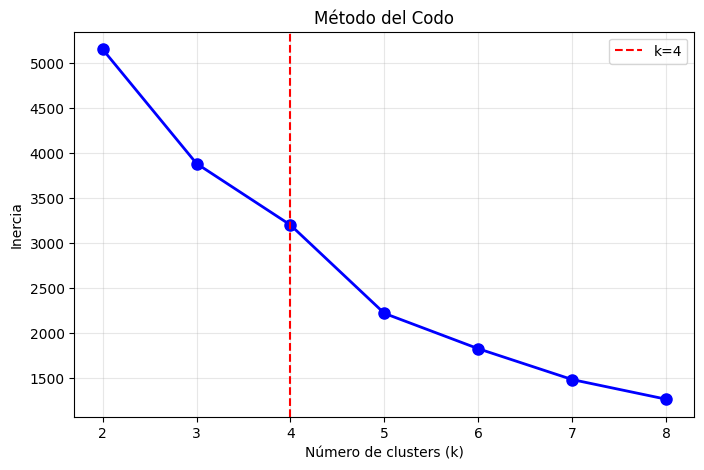


✅ Elegimos k = 4 clusters


In [9]:
# ============================================================
# MÉTODO DEL CODO: DETERMINAR K ÓPTIMO
# ============================================================

inercia = []
K_range = range(2, 9)

print("🔍 Calculando inercia para k = 2 a 8...")

for k in K_range:
    kmeans_temp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_temp.fit(X_cluster_scaled)
    inercia.append(kmeans_temp.inertia_)
    print(f"   k = {k} → inercia = {inercia[-1]:.2f}")

plt.figure(figsize=(8, 5))
plt.plot(K_range, inercia, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo')
plt.grid(alpha=0.3)
plt.axvline(x=4, color='r', linestyle='--', label='k=4')
plt.legend()
plt.show()

print("\n✅ Elegimos k = 4 clusters")
k_optimo = 4

In [10]:
# ============================================================
# EJECUTAR K-MEANS CON K=4
# ============================================================

kmeans = KMeans(n_clusters=k_optimo, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_cluster_scaled)

df_wheat_barley_cluster = df_wheat_barley.loc[df_cluster.index].copy()
df_wheat_barley_cluster['Cluster'] = clusters

print("✅ Clustering completado")
print(f"   Distribución de clusters:")
for i in range(k_optimo):
    count = (clusters == i).sum()
    print(f"   Cluster {i}: {count} muestras ({count/len(clusters)*100:.1f}%)")

✅ Clustering completado
   Distribución de clusters:
   Cluster 0: 179 muestras (15.6%)
   Cluster 1: 251 muestras (21.9%)
   Cluster 2: 186 muestras (16.2%)
   Cluster 3: 531 muestras (46.3%)


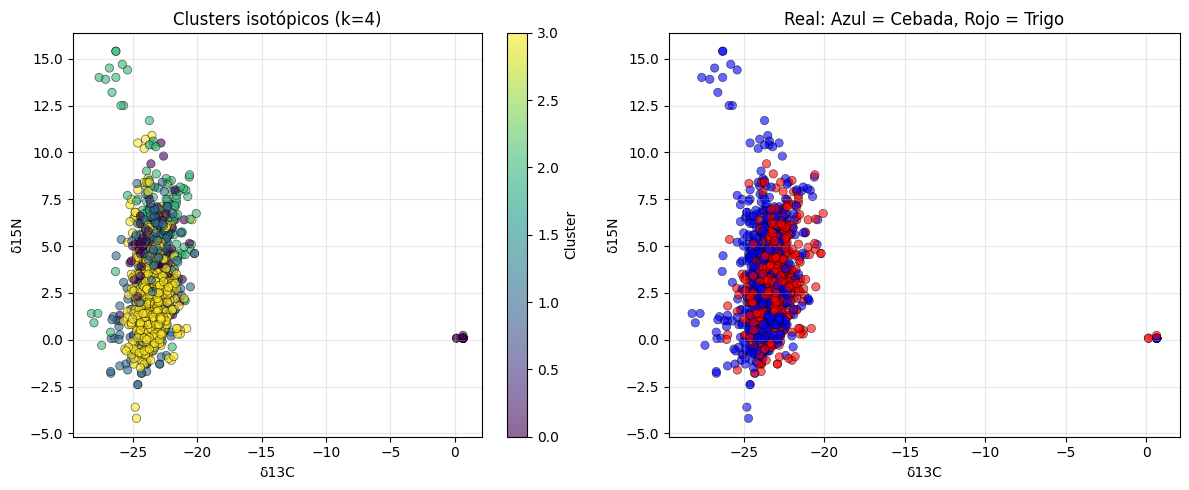

✅ Listo. Ahora puedes comparar clusters vs realidad


In [11]:
# ============================================================
# VISUALIZACIÓN: CLUSTERS EN ESPACIO ISOTÓPICO
# ============================================================

plt.figure(figsize=(12, 5))

# Gráfico 1: Clusters
plt.subplot(1, 2, 1)
scatter = plt.scatter(
    df_wheat_barley_cluster['IRMS_d13C_Collagen'],
    df_wheat_barley_cluster['d15N_Collagen'],
    c=df_wheat_barley_cluster['Cluster'],
    cmap='viridis',
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
plt.xlabel('δ13C')
plt.ylabel('δ15N')
plt.title('Clusters isotópicos (k=4)')
plt.colorbar(scatter, label='Cluster')
plt.grid(alpha=0.3)

# Gráfico 2: Cereal real
plt.subplot(1, 2, 2)
cereal_color = {'barley': 'blue', 'wheat': 'red'}
colors = [cereal_color[c] for c in df_wheat_barley_cluster['Cereal']]
plt.scatter(
    df_wheat_barley_cluster['IRMS_d13C_Collagen'],
    df_wheat_barley_cluster['d15N_Collagen'],
    c=colors,
    alpha=0.6,
    edgecolors='k',
    linewidth=0.5
)
plt.xlabel('δ13C')
plt.ylabel('δ15N')
plt.title('Real: Azul = Cebada, Rojo = Trigo')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("✅ Listo. Ahora puedes comparar clusters vs realidad")

In [ ]:
#pip install folium

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


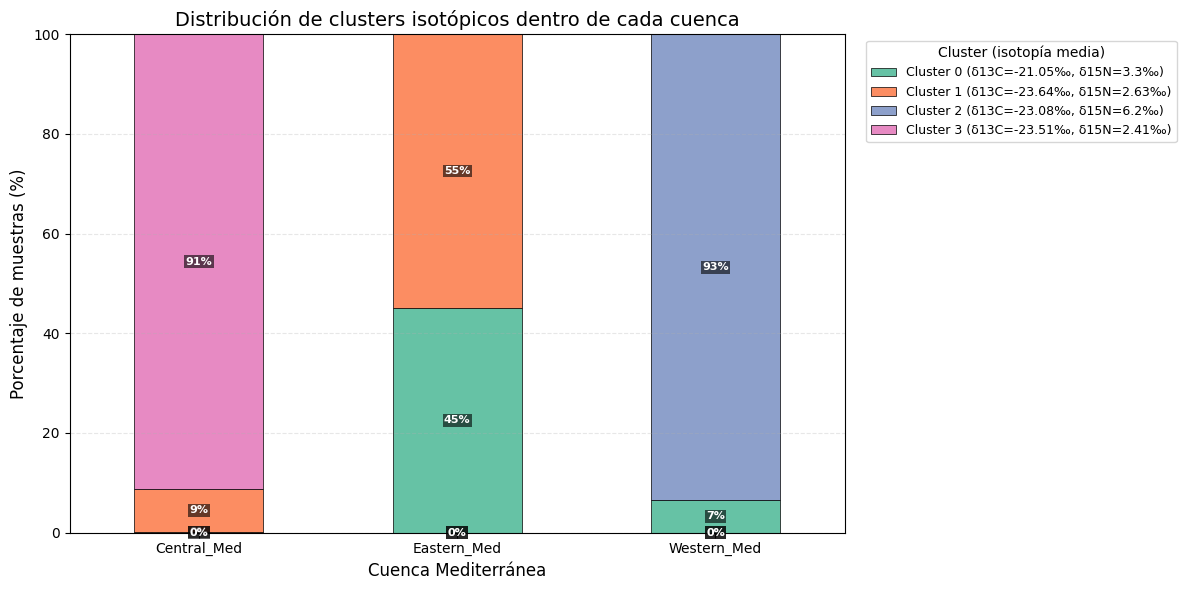


📊 INTERPRETACIÓN DEL GRÁFICO

🔍 Este gráfico muestra cómo se distribuyen los diferentes clusters (grupos isotópicos)
dentro de cada cuenca del Mediterráneo.

📌 CLUSTER 0: δ13C más negativo → mayor estrés hídrico (sequía)
📌 CLUSTER 3: δ15N más positivo → suelos más áridos o fertilización

✅ PREGUNTAS QUE PUEDES RESPONDER EN TU PRESENTACIÓN:
• ¿Hay un cluster que domine claramente en una cuenca? → homogeneidad ambiental
• ¿Varios clusters se mezclan en una misma cuenca? → diversidad de prácticas agrícolas
• ¿La cuenca occidental tiene clusters diferentes a la oriental? → gradiente climático



In [17]:
# ============================================================
# GRÁFICO DE BARRAS APILADAS CON LEYENDA DESCRIPTIVA
# ============================================================

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tabla de contingencia normalizada por cuenca
contingencia = pd.crosstab(
    df_wheat_barley_cluster['Cluster'],
    df_wheat_barley_cluster['Mediterranean_Basin'],
    normalize='columns'
) * 100

# 2. Perfiles isotópicos para la leyenda
perfil = df_wheat_barley_cluster.groupby('Cluster')[['IRMS_d13C_Collagen', 'd15N_Collagen']].mean().round(2)

# 3. Etiquetas descriptivas para la leyenda
etiquetas_cluster = [
    f'Cluster 0 (δ13C={perfil.loc[0, "IRMS_d13C_Collagen"]}‰, δ15N={perfil.loc[0, "d15N_Collagen"]}‰)',
    f'Cluster 1 (δ13C={perfil.loc[1, "IRMS_d13C_Collagen"]}‰, δ15N={perfil.loc[1, "d15N_Collagen"]}‰)',
    f'Cluster 2 (δ13C={perfil.loc[2, "IRMS_d13C_Collagen"]}‰, δ15N={perfil.loc[2, "d15N_Collagen"]}‰)',
    f'Cluster 3 (δ13C={perfil.loc[3, "IRMS_d13C_Collagen"]}‰, δ15N={perfil.loc[3, "d15N_Collagen"]}‰)'
]

# Renombrar índices del dataframe de contingencia
contingencia.index = etiquetas_cluster

# 4. Gráfico
colores_claros = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

fig, ax = plt.subplots(figsize=(12, 6))
contingencia.T.plot(kind='bar', stacked=True, ax=ax, color=colores_claros, edgecolor='black', linewidth=0.5)

plt.xlabel('Cuenca Mediterránea', fontsize=12)
plt.ylabel('Porcentaje de muestras (%)', fontsize=12)
plt.title('Distribución de clusters isotópicos dentro de cada cuenca', fontsize=14)
plt.legend(title='Cluster (isotopía media)', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
plt.xticks(rotation=0)
plt.ylim(0, 100)

# Etiquetas de porcentaje dentro de las barras
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', label_type='center', fontsize=8,
                 color='white', weight='bold', bbox=dict(facecolor='black', edgecolor='none', alpha=0.6, pad=1))

plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

# ============================================================
# INTERPRETACIÓN PARA PRESENTACIÓN
# ============================================================
print("\n" + "="*70)
print("📊 INTERPRETACIÓN DEL GRÁFICO")
print("="*70)
print("""
🔍 Este gráfico muestra cómo se distribuyen los diferentes clusters (grupos isotópicos)
dentro de cada cuenca del Mediterráneo.

📌 CLUSTER 0: δ13C más negativo → mayor estrés hídrico (sequía)
📌 CLUSTER 3: δ15N más positivo → suelos más áridos o fertilización

✅ PREGUNTAS QUE PUEDES RESPONDER EN TU PRESENTACIÓN:
• ¿Hay un cluster que domine claramente en una cuenca? → homogeneidad ambiental
• ¿Varios clusters se mezclan en una misma cuenca? → diversidad de prácticas agrícolas
• ¿La cuenca occidental tiene clusters diferentes a la oriental? → gradiente climático
""")